In [1]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

In [2]:
from sklearn.preprocessing import StandardScaler
scalr = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"K={k} → Accuracy: {accuracy_score(y_test, y_pred):.2f}")

K=1 → Accuracy: 0.97
K=2 → Accuracy: 1.00
K=3 → Accuracy: 1.00
K=4 → Accuracy: 1.00
K=5 → Accuracy: 1.00
K=6 → Accuracy: 1.00
K=7 → Accuracy: 1.00
K=8 → Accuracy: 1.00
K=9 → Accuracy: 1.00
K=10 → Accuracy: 1.00


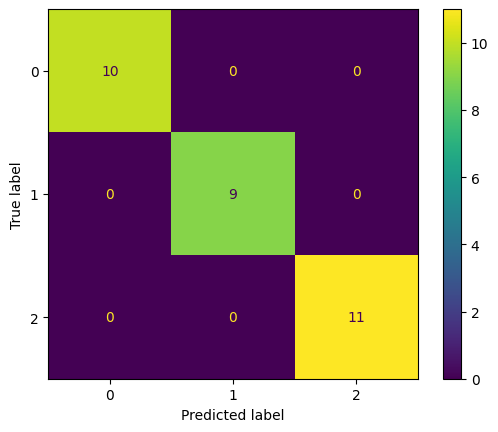

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
best_k = 3 
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)

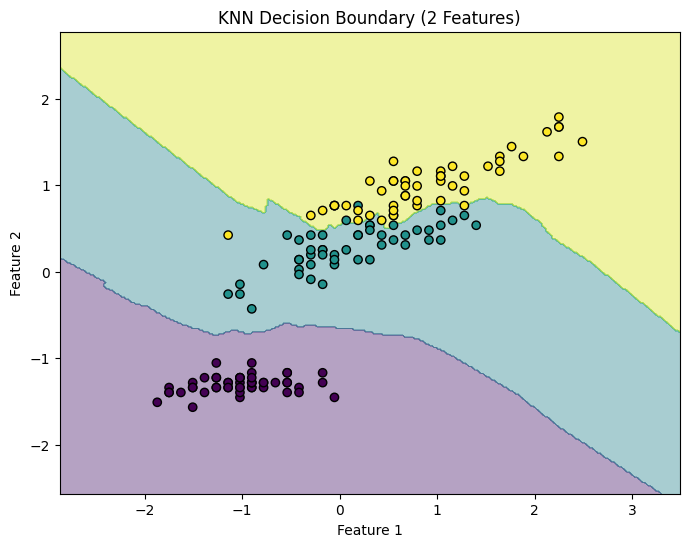

In [6]:
import matplotlib.pyplot as plt
import numpy as np
X_vis = X_scaled[:, [0, 2]] 
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_vis, y_train_vis)
h = 0.02
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KNN Decision Boundary (2 Features)')
plt.savefig("knn_decision_boundary.png")
plt.show()